In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import numpy as np

In [3]:
df = pd.read_csv("r_acc_v1.csv", header=None, comment='#', names=['No', 'Time', 'Source', 'Target', 'Content'])
df = pd.read_csv("r.csv", header=None, comment='#', names=['No', 'Time', 'Source', 'Target', 'Content'])
#df[df["Source"]==10778]
df[df["Target"]==10778]

,No,Time,Source,Target,Content
7546,7546,55027.0,10080,10778,1


In [4]:
df

,No,Time,Source,Target,Content
0,0,50023.0,9780,9737,0
1,1,50024.0,9737,9780,0
2,2,50024.0,9737,9738,0
3,3,50025.0,9738,9737,0
4,4,50026.0,9738,9780,0
...,...,...,...,...,...
11452,11452,59988.0,11139,11019,0
11453,11453,59993.0,10922,11405,0
11454,11454,59993.0,10998,11155,0
11455,11455,59993.0,11155,10998,0


In [5]:
nodes={}
for i in range(len(df)):
    d=df.iloc[i]
    if d["Target"] not in nodes.keys():
        nodes[d["Target"]]={"time":d["Time"],"from":d["Source"],"to":[],"connect":[],"content":d["Content"],"content_0":0,"content_1":0}
        if d["Source"] in nodes.keys():
            nodes[d["Source"]]["to"].append(d["Target"])
for i in range(len(df)):
    d=df.iloc[i]
    nodes[d["Source"]]["connect"].append(d["Target"])
    nodes[d["Target"]]["connect"].append(d["Source"])
    nodes[d["Source"]][f"content_{int(d["Content"])}"]+=1

In [6]:
nodes

{np.float64(9737.0): {'time': np.float64(50023.0),
  'from': np.float64(9780.0),
  'to': [np.float64(9780.0), np.float64(9738.0)],
  'connect': [np.float64(9780.0),
   np.float64(9780.0),
   np.float64(9738.0),
   np.float64(9738.0),
   np.float64(9780.0),
   np.float64(9780.0),
   np.float64(9738.0)],
  'content': np.float64(0.0),
  'content_0': 2,
  'content_1': 2},
 np.float64(9780.0): {'time': np.float64(50024.0),
  'from': np.float64(9737.0),
  'to': [np.float64(2429.0),
   np.float64(9251.0),
   np.float64(2436.0),
   np.float64(5263.0),
   np.float64(9746.0),
   np.float64(4341.0),
   np.float64(8763.0),
   np.float64(5269.0),
   np.float64(4344.0),
   np.float64(4345.0),
   np.float64(5271.0)],
  'connect': [np.float64(9737.0),
   np.float64(9737.0),
   np.float64(9738.0),
   np.float64(9738.0),
   np.float64(2429.0),
   np.float64(2429.0),
   np.float64(9251.0),
   np.float64(9251.0),
   np.float64(2436.0),
   np.float64(2436.0),
   np.float64(3347.0),
   np.float64(3347.0),
 

In [7]:
end=[]
k=list(nodes.keys())
k.reverse()
pos=0
while len(k)>0:
    key=k[0]
    if key in end:
        k.pop(0)
        continue
    print(key,nodes[key])
    nodes[key]["pos"]=(nodes[key]["time"],pos)
    pos+=1
    end.append(key)
    k.pop(0)
    k.insert(0,nodes[key]["from"])
    for v in nodes[key]["to"]:
        k.insert(0,v)
nodes

11040.0 {'time': np.float64(59932.0), 'from': np.float64(11088.0), 'to': [], 'connect': [np.float64(11088.0), np.float64(11088.0)], 'content': np.float64(0.0), 'content_0': 1, 'content_1': 0}
11088.0 {'time': np.float64(59180.0), 'from': np.float64(10924.0), 'to': [np.float64(11095.0), np.float64(11040.0)], 'connect': [np.float64(10924.0), np.float64(10924.0), np.float64(11095.0), np.float64(11095.0), np.float64(11150.0), np.float64(11150.0), np.float64(10723.0), np.float64(10723.0), np.float64(11166.0), np.float64(11166.0), np.float64(10958.0), np.float64(10958.0), np.float64(10754.0), np.float64(10754.0), np.float64(10792.0), np.float64(10792.0), np.float64(10822.0), np.float64(10822.0), np.float64(10842.0), np.float64(10842.0), np.float64(11099.0), np.float64(11099.0), np.float64(10882.0), np.float64(10882.0), np.float64(11155.0), np.float64(11155.0), np.float64(11158.0), np.float64(11158.0), np.float64(11363.0), np.float64(11363.0), np.float64(10947.0), np.float64(10947.0), np.floa

{np.float64(9737.0): {'time': np.float64(50023.0),
  'from': np.float64(9780.0),
  'to': [np.float64(9780.0), np.float64(9738.0)],
  'connect': [np.float64(9780.0),
   np.float64(9780.0),
   np.float64(9738.0),
   np.float64(9738.0),
   np.float64(9780.0),
   np.float64(9780.0),
   np.float64(9738.0)],
  'content': np.float64(0.0),
  'content_0': 2,
  'content_1': 2,
  'pos': (np.float64(50023.0), 434)},
 np.float64(9780.0): {'time': np.float64(50024.0),
  'from': np.float64(9737.0),
  'to': [np.float64(2429.0),
   np.float64(9251.0),
   np.float64(2436.0),
   np.float64(5263.0),
   np.float64(9746.0),
   np.float64(4341.0),
   np.float64(8763.0),
   np.float64(5269.0),
   np.float64(4344.0),
   np.float64(4345.0),
   np.float64(5271.0)],
  'connect': [np.float64(9737.0),
   np.float64(9737.0),
   np.float64(9738.0),
   np.float64(9738.0),
   np.float64(2429.0),
   np.float64(2429.0),
   np.float64(9251.0),
   np.float64(9251.0),
   np.float64(2436.0),
   np.float64(2436.0),
   np.floa

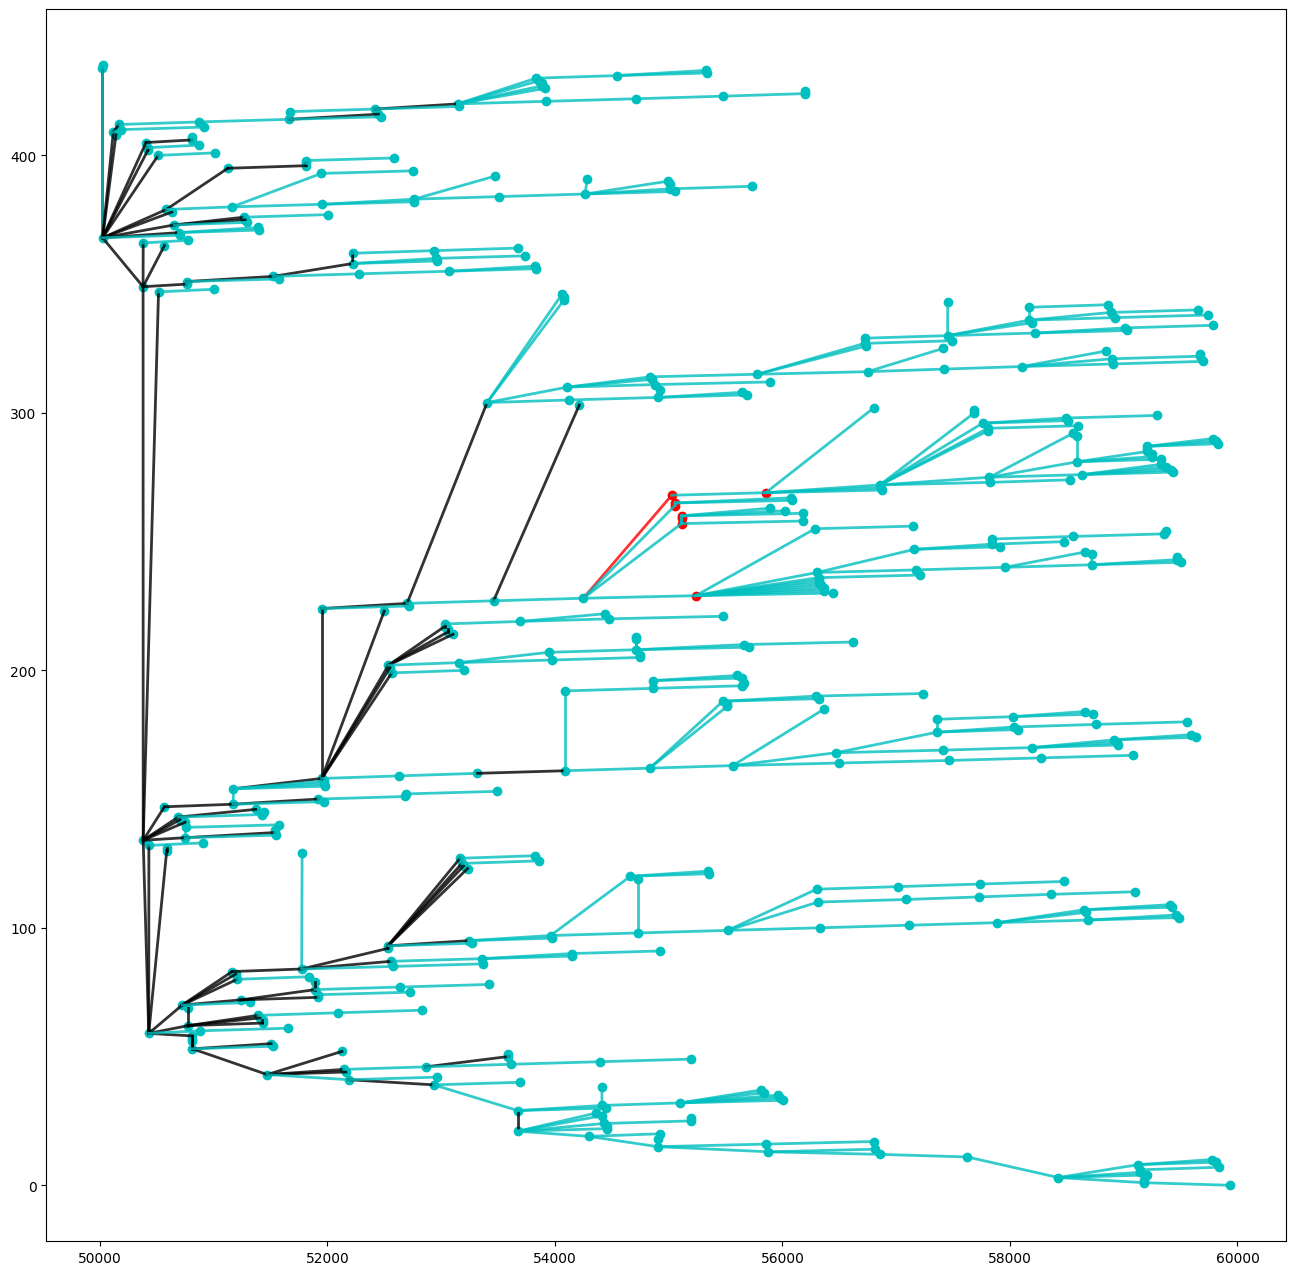

In [8]:
fig=plt.figure(figsize=(16,16))
axe=fig.add_subplot(111)
xs,ys=[],[]
xs2,ys2=[],[]
for n in nodes:
    try:
        if nodes[n]["content"]==0:
            xs.append(nodes[n]["pos"][0])
            ys.append(nodes[n]["pos"][1])
        else:
            xs2.append(nodes[n]["pos"][0])
            ys2.append(nodes[n]["pos"][1])
    except Exception:
        print(nodes[n])
axe.scatter(xs,ys,color="c")
axe.scatter(xs2,ys2,color="r")

for n in nodes:
    color="c" if nodes[n]["content"]==0 else "r"
    color="c"
    if nodes[n]["content_0"]==nodes[n]["content_1"]:
        color="k"
    if nodes[n]["content_0"]<nodes[n]["content_1"]:
        color="r"
    to_node=nodes[n]
    from_node=nodes[nodes[n]["from"]]
    
    # 通信線（縦線または斜め線）の描画
    # zorder=3 でライフラインの上に描画
    axe.plot([from_node["pos"][0], to_node["pos"][0]], [from_node["pos"][1], to_node["pos"][1]], 
            color=color, linewidth=2, linestyle='-', alpha=0.8, zorder=3)
    if 0:
        for cn in to_node["connect"]:
            cnn=nodes[cn]
            axe.plot([cnn["pos"][0], to_node["pos"][0]], [cnn["pos"][1], to_node["pos"][1]], 
                    color="g", linewidth=1, linestyle='dashed', alpha=0.1, zorder=2)

  0%|          | 0/11457 [00:00<?, ?it/s]

100%|██████████| 11457/11457 [00:06<00:00, 1832.53it/s]


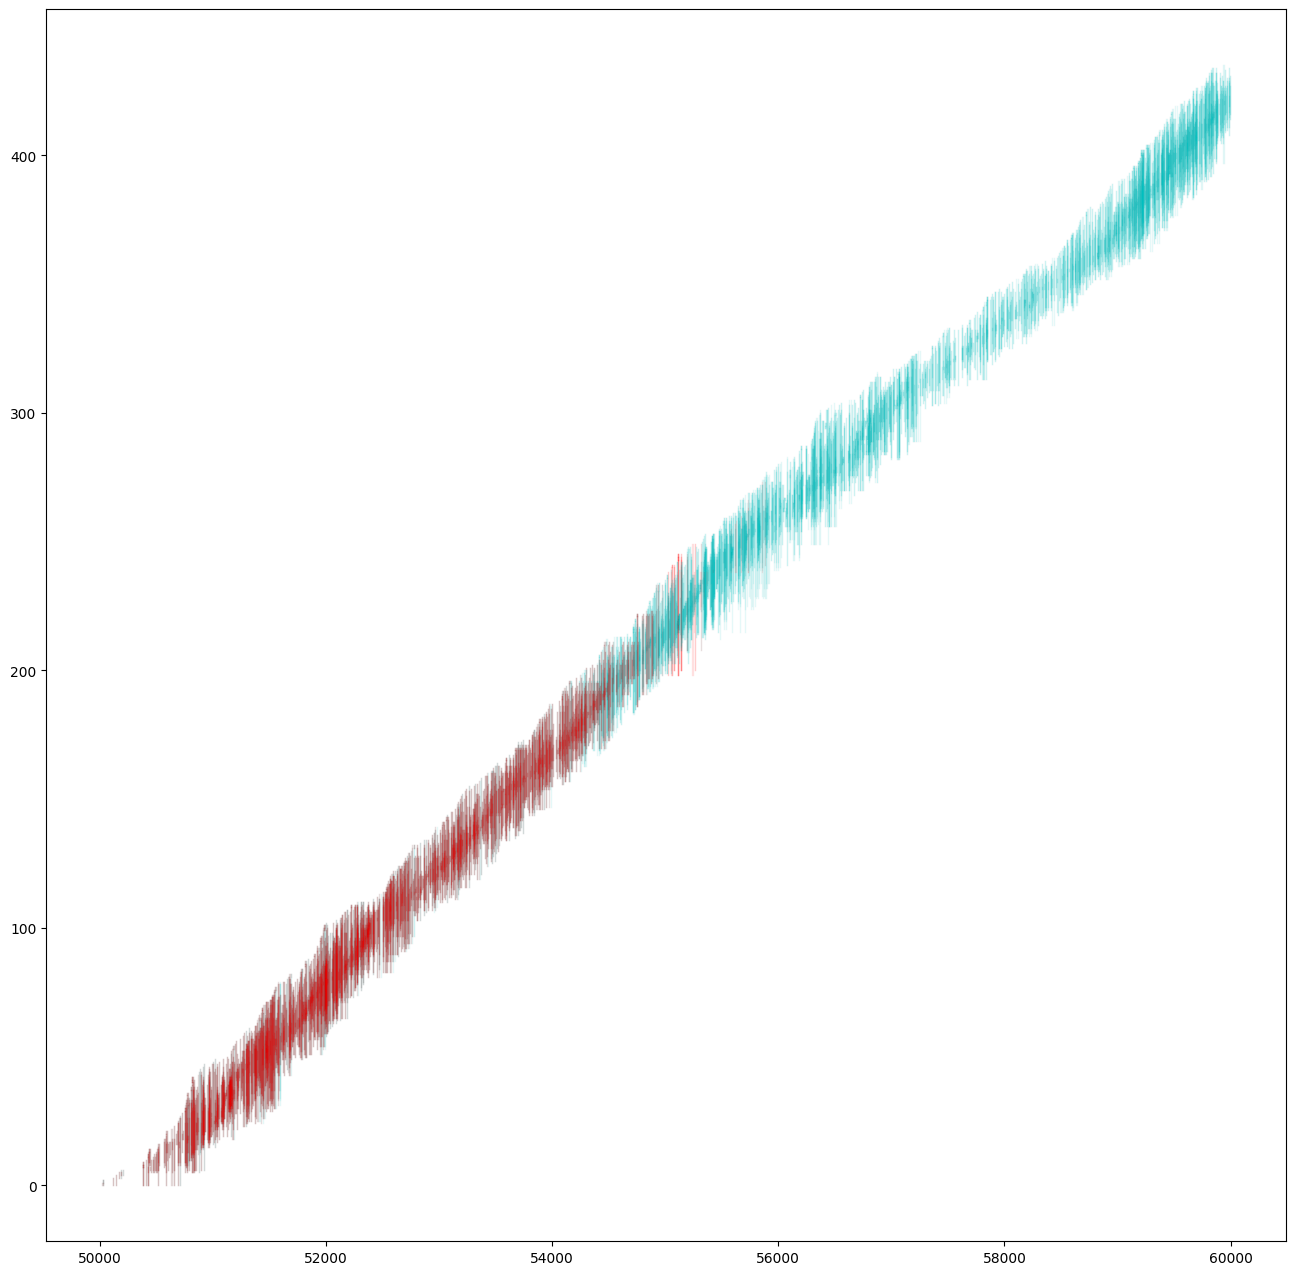

In [11]:
from tqdm import tqdm
pos_y={}
fig=plt.figure(figsize=(16,16))
axe=fig.add_subplot(111)
for i in tqdm(range(len(df))):
    d=df.iloc[i]
    color="c" if d["Content"]==0 else "r"
    if d["Source"] not in pos_y.keys():
        pos_y[d["Source"]]=len(pos_y.keys())
    if d["Target"] not in pos_y.keys():
        pos_y[d["Target"]]=len(pos_y.keys())
    axe.plot([d["Time"],d["Time"]], [pos_y[d["Source"]], pos_y[d["Target"]]], 
        color=color, linewidth=1, linestyle='-', alpha=0.1, zorder=2)